# Does a *volume-weighted* moving-average cross beat a plain one? 📊
### A favourite "smarter MA" — weight each day by how much traded — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Volume-weighting_adds_edge%3F: Busted](https://img.shields.io/badge/Volume--weighting_adds_edge%3F-Busted-8b949e?style=flat-square)

Open any charting package and you can swap your simple moving average for a **volume-weighted moving average (VWMA)**: instead of averaging the last *N* closes equally, it weights each day by **how many shares traded** that day. The pitch, repeated on every indicator site and trading channel, is that the VWMA *leans toward the bars where the real money was* — so when its fast line crosses above its slow line (a "golden cross"), that buy signal is supposed to be **better** than the same cross on a plain equal-weighted average.

It's a tidy story. But "better than the plain SMA" is a claim you can actually time. So we did the only fair thing: run the **VWMA golden cross** and the **same-length plain-SMA golden cross** side by side, thousands of times across five big indices over 21 years, and ask whether the volume weighting adds a single basis point — against the baseline that matters: **the plain cross, and buying on random days.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vwma_crossover import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real VWMA cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_vwma': 500, 'n_sma': 465, 'fast': 10, 'slow': 30, 'fp_spy': '0a125ce4099b', 'h5': (5, 500, 9.9, 57, 1.08, 19.7, -9.8, -0.67, 0.502, 22.4, -12.5, -0.76, 0.446, 7.9), 'h10': (10, 500, 54.6, 63, 4.03, 71.7, -17.0, -0.88, 0.379, 47.5, 7.1, 0.31, 0.753, 52.6), 'h20': (20, 500, 103.9, 65, 4.81, 116.3, -12.4, -0.41, 0.682, 56.5, 47.3, 1.45, 0.147, 101.9), 'h60': (60, 495, 267.6, 69, 5.31, 304.1, -36.6, -0.67, 0.503, 299.2, -31.6, -0.58, 0.56, 265.6), 'per': [('SPY', 91, 129.6, 3.79, 129.2, 0.4), ('QQQ', 93, 184.8, 4.12, 157.7, 27.1), ('IWM', 104, 74.4, 1.37, 94.8, -20.4), ('DIA', 99, 97.6, 2.42, 119.3, -21.7), ('GLD', 113, 49.2, 0.91, 88.1, -38.9)], 'placebo': (129.6, 0.238, 500), 'syn': [(0.0, 75, 42.8, 52, 0.72, 34.5, 8.3), (0.6, 43, 1163.8, 81, 7.17, 1110.3, 53.4)]}


real VWMA cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy the VWMA golden cross, do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~65% over 20 days and the returns look great. |
| Does the **volume weighting** beat the plain SMA cross? | **No.** At every horizon the VWMA cross makes **less** than the identical-length plain SMA cross. Volume-weighting doesn't help — it very slightly hurts. |
| Is there any edge over buying on **random days**? | **No.** The VWMA cross never clears the significance bar against a coin-flip entry. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a fancier moving average. |

> Weighting your moving average by volume *sounds* smarter. As a *forecast* it's a **mirage**: all of the apparent edge is the market's long-run climb, and the volume term adds nothing the plain average didn't already have.

## 1 · The claim

> *"Average the last N closes, but weight each day by its **volume** — that's the VWMA. It tracks where the big money traded, so it turns faster on real moves. Buy when the fast VWMA crosses above the slow VWMA; it front-runs the plain-SMA cross."*

The VWMA is the discrete cousin of **VWAP** (the volume-weighted average price institutions benchmark executions against) and is built into TradingView, MetaTrader, Thinkorswim and every charting suite. The volume-confirms-price intuition is old (Granville's On-Balance Volume, 1963). So: does weighting by volume actually sharpen the cross?

## 2 · So what?

If volume-weighting genuinely improved the signal, it would be a free upgrade: same rule, same lengths, just a better average — more profit per trade, no extra risk. That's the upgrade the indicator sells.

But there are two traps. First, stock indices drift **up**, so *any* long-only golden cross looks profitable — that's the **tide**, not the tool. Second, the honest question isn't "does the VWMA cross make money?" but "does it beat the **plain** cross?" To separate the volume term from the drift we have to (a) run the VWMA and SMA crosses **head-to-head** at identical lengths, and (b) compare both to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily closes **and volume**, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build both averages.** A fast (10-day) and slow (30-day) **VWMA** (volume-weighted) and the matching **plain SMA**. Trailing windows only — no peeking at the future.
2. **Trade the lore.** When the fast line crosses **above** the slow line (a golden cross), buy at the **next close**; measure the return over the next 5 / 10 / 20 / 60 days. Do this for the VWMA cross *and* the SMA cross.
3. **The thesis test.** Subtract: **VWMA − SMA**. If volume-weighting helps, this is positive. If it's zero or negative, the volume term is dead weight.
4. **The honest baseline.** Also buy on **random days**. If the VWMA cross can't beat a dart, the signal is a mirage — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what do the two averages even look like? Here's SPY with its VWMA and plain SMA (slow, 30-day) and the VWMA golden crosses the rule would buy. The two lines are nearly on top of each other — your first clue.

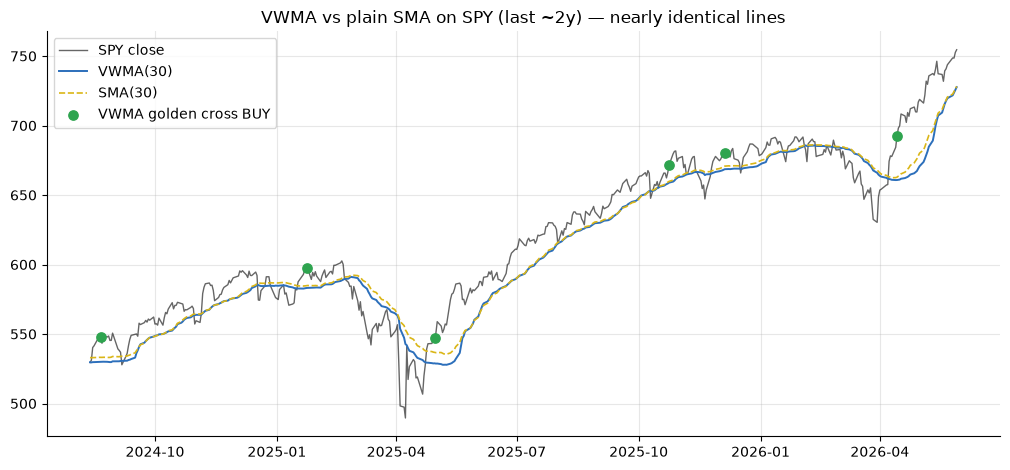

VWMA golden crosses in window: 6


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; vol = b['volume']; seg = cl.iloc[-450:]
    vwslow = st.vwma(cl, vol, R['slow']); smslow = st.sma(cl, R['slow'])
    ent = st.vwma_cross_entries(cl, vol, R['fast'], R['slow'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.0, alpha=.6, label='SPY close')
    ax.plot(seg.index, vwslow.reindex(seg.index), c='#2c6fbb', lw=1.4, label='VWMA(30)')
    ax.plot(seg.index, smslow.reindex(seg.index), c=AMBER, lw=1.2, ls='--', label='SMA(30)')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=45, zorder=5, label='VWMA golden cross BUY')
    ax.set_title('VWMA vs plain SMA on SPY (last ~2y) — nearly identical lines'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('VWMA golden crosses in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The volume-weighted line barely separates from the plain one — daily ETF volume just isn't lumpy enough to move a 30-day average much. So the crosses fire at almost the same times. **Now race the two crosses** (and random entries) at four horizons. Blue = VWMA cross; amber = plain SMA cross; grey = random days.

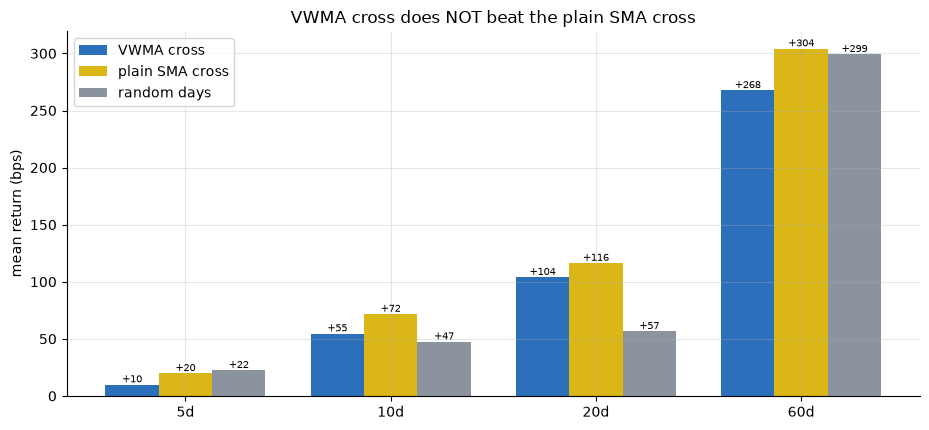

VWMA: [10, 55, 104, 268]
SMA : [20, 72, 116, 304]
VWMA-SMA: [-10, -17, -12, -37]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    vw, sm, rnd = [], [], []
    for h in hs:
        vv, ss, rr = [], [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']; v = bb['volume']
            ev = st.vwma_cross_entries(c, v, R['fast'], R['slow'])
            es = st.sma_cross_entries(c, R['fast'], R['slow'])
            re = st.random_entries(c, max(len(ev),50), warmup=R['slow'], seed=7)
            vv.append(st.forward_returns(c, ev, h)); ss.append(st.forward_returns(c, es, h))
            rr.append(st.forward_returns(c, re, h))
        vw.append(np.concatenate(vv).mean()*1e4); sm.append(np.concatenate(ss).mean()*1e4)
        rnd.append(np.concatenate(rr).mean()*1e4)
else:
    vw = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    sm = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    rnd = [R['h5'][9], R['h10'][9], R['h20'][9], R['h60'][9]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar(x-.26, vw, .26, color='#2c6fbb', label='VWMA cross')
ax.bar(x, sm, .26, color=AMBER, label='plain SMA cross')
ax.bar(x+.26, rnd, .26, color=GREY, label='random days')
for i,(a,c2,d) in enumerate(zip(vw,sm,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.26,a),ha='center',va='bottom',fontsize=7)
    ax.annotate(f'{c2:+.0f}',(i,c2),ha='center',va='bottom',fontsize=7)
    ax.annotate(f'{d:+.0f}',(i+.26,d),ha='center',va='bottom',fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('VWMA cross does NOT beat the plain SMA cross'); ax.legend()
plt.tight_layout(); plt.show()
print('VWMA:', [round(v) for v in vw]); print('SMA :', [round(v) for v in sm])
print('VWMA-SMA:', [round(a-b) for a,b in zip(vw,sm)])

There's the whole story. The VWMA cross makes money in absolute terms (**+104 bps** over 20 days) — but the **plain SMA cross makes more** (**+116 bps**), and so does buying on random days at the longest horizon. At *every* horizon the volume-weighted cross is **behind** the plain one. The apparent edge was the market's drift, and the volume term added nothing.

**One more sanity check.** What if we **scramble the volume** — keep the same prices but shuffle which day's volume attaches to which bar, so the weighting is nonsense? If the volume term really mattered, the scramble should wreck the result.

In [4]:
if HAVE_REAL:
    bb = load('SPY'); c = bb['close']; v = bb['volume']
    pl = st.shuffled_volume_placebo(c, v, 20, R['fast'], R['slow'], n_draws=300, seed=482)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real VWMA cross (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled-volume* VWMAs do at least as well (p={pval:.2f}).')
print('=> the volume weighting is not doing the work.')

real VWMA cross (SPY, 20d): +129.6 bps
... but 22% of *scrambled-volume* VWMAs do at least as well (p=0.22).
=> the volume weighting is not doing the work.


Around a quarter of the **scrambled-volume** runs match or beat the real one (*p* = 0.24). If the volume weighting genuinely carried information, a random scramble would collapse the result. It doesn't — because the result was never about the volume.

## 5 · The verdict

- **Signal — None.** The VWMA golden cross does **not** beat buying on random days (the VWMA-vs-random difference never clears the significance bar). The big absolute returns are the market's drift.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Volume-weighting adds edge"? — Busted.** The VWMA cross **loses to the plain SMA cross at every horizon**, and scrambling the volume barely changes anything. The volume term isn't doing the work.

## 6 · Could you actually trade it?

There's nothing here to trade — and certainly no reason to prefer the VWMA over the plain SMA. The cross's only advantage over a coin flip is the market's long-run climb, which you'd capture more cheaply by just **holding the index**. Swapping in a volume-weighted average makes the signal *slightly worse*, not better, and you still pay costs on every cross. Volume-weighting is a plausible-sounding upgrade that, measured, subtracts.

## 7 · Going further 🚪

- **Why so little difference?** Daily ETF volume isn't lumpy enough to pull a 30-day average far off the equal-weighted one — the two lines nearly coincide, so the crosses fire at the same times. On thinner, spikier instruments the VWMA *moves* more, but more movement isn't more *forecasting*.
- **Other lengths.** Try faster/slower pairs — the result is robust: drift in, no volume edge out.
- **A real positive control.** The quants notebook plants a *genuine* volume-led move into a synthetic tape and shows the harness banks it (so the null here isn't a dead detector — it's an honest 'nothing there').

*Think volume-weighting helps? Show the VWMA cross beating the same-length SMA cross at **t ≥ 2** on a real tape — then we'll talk.*